In [2]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom as dcm
import math
import os

## Processing of dose and LET data in water phantom

This is the data that I got from running a simulation in a water phantom. I will plot them together with curves from RayPhysics to verify correctness.

In [3]:
path = r"C:\Users\bhaan\Downloads\Unrestricted beam plan - LET and RTStruct wo range shifter\roi_let_dose_coords_WaterPhantom.csv"
data_waterphantom = pd.read_csv(path)

#Find middle x and y
x_mid = np.unique(data_waterphantom['x_mm'])[round(len(np.unique(data_waterphantom['x_mm']))/2)]
z_mid = np.unique(data_waterphantom['z_mm'])[round(len(np.unique(data_waterphantom['z_mm']))/2)]

#Extract data with this x and y
lineprofile = data_waterphantom[(data_waterphantom['x_mm']==x_mid) & (data_waterphantom['z_mm']==z_mid)]
print(lineprofile)

          x_mm     y_mm    z_mm  LET_keV_per_um   Dose_Gy  LET_vektet_dose
667898 -0.2404 -135.029 -225.05        2.741313  0.000041         0.000047
667993 -0.2404 -134.729 -225.05        2.714425  0.000016         0.000019
668088 -0.2404 -134.429 -225.05        0.000000  0.000000         0.000000
668183 -0.2404 -134.129 -225.05        2.377136  0.000006         0.000007
668278 -0.2404 -133.829 -225.05        2.904258  0.000067         0.000078
...        ...      ...     ...             ...       ...              ...
685473 -0.2404  -79.529 -225.05        1.132318  0.470687         0.500000
685568 -0.2404  -79.229 -225.05        1.061322  0.465998         0.493200
685663 -0.2404  -78.929 -225.05        1.059537  0.466506         0.493691
685758 -0.2404  -78.629 -225.05        1.059925  0.464723         0.491815
685853 -0.2404  -78.329 -225.05        1.039072  0.459429         0.485684

[190 rows x 6 columns]


In [4]:
#Process data
ydata = np.array(abs(lineprofile['y_mm']))
letdata = np.array(lineprofile['LET_keV_per_um'])
dosedata = np.array(lineprofile['Dose_Gy'])

#Want depth to start at zero
ydata = ydata - min(ydata)
#Sort depth data in ascending order
sort = np.argsort(ydata)
#Apply sorting to all variables
ydata = ydata[sort]
letdata = letdata[sort]
dosedata = dosedata[sort]

#Truncate data once dose drops to zero
stopindex = np.where(dosedata==0)[0][0]
ydata = ydata[0:stopindex]
letdata = letdata[0:stopindex]
dosedata = dosedata[0:stopindex]

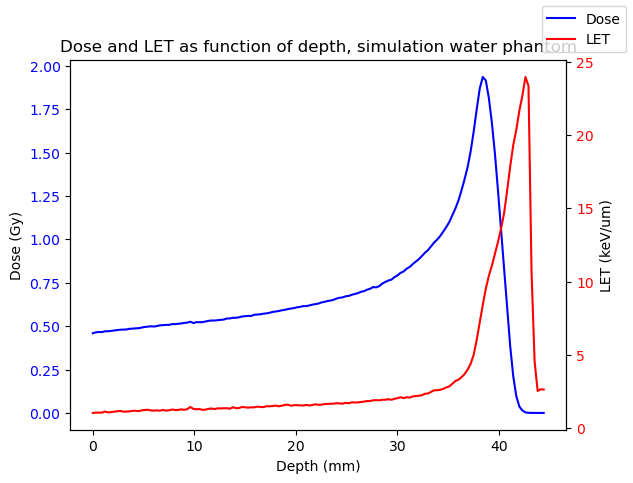

In [15]:
#Plot lineprofile as function of depth
fig, ax1 = plt.subplots()

ax1.plot(ydata, dosedata, label='Dose', color='b')
ax1.set_xlabel('Depth (mm)')
ax1.set_ylabel('Dose (Gy)')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
ax2.plot(ydata, letdata, label='LET', color='r')
ax2.set_ylabel('LET (keV/um)')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Dose and LET as function of depth, simulation water phantom')

fig.legend()

In [16]:
### Measured BP data from RayPhysics ###
path = r"C:\Users\bhaan\Downloads\MeasuredBP_69MeV.xlsx"
data = pd.read_excel(path)

RSdepth_m = np.array(data['Depth'])
RSdose_m = np.array(data['Dose'])

#Want depth to start at zero
RSdepth_m = RSdepth_m #- min(RSdepth)
#Sort depth data in ascending order
sort = np.argsort(RSdepth_m)
#Apply sorting to all variables
RSdepth_m = RSdepth_m[sort]
RSdose_m = RSdose_m[sort]

#Want dose and let normalised to maximum
RSdose_m = RSdose_m/max(RSdose_m)

### Calculated BP data from RayPhysics ###
path = r"C:\Users\bhaan\Downloads\CalculatedBP_69MeV.xlsx"
data = pd.read_excel(path)

RSdepth_c = np.array(data['Depth'])
RSdose_c = np.array(data['Dose'])

#Want depth to start at zero
RSdepth_c = RSdepth_c #- min(RSdepth)
#Sort depth data in ascending order
sort = np.argsort(RSdepth_c)
#Apply sorting to all variables
RSdepth_c = RSdepth_c[sort]
RSdose_c = RSdose_c[sort]

#Want dose and let normalised to maximum
RSdose_c = RSdose_c/max(RSdose_c)

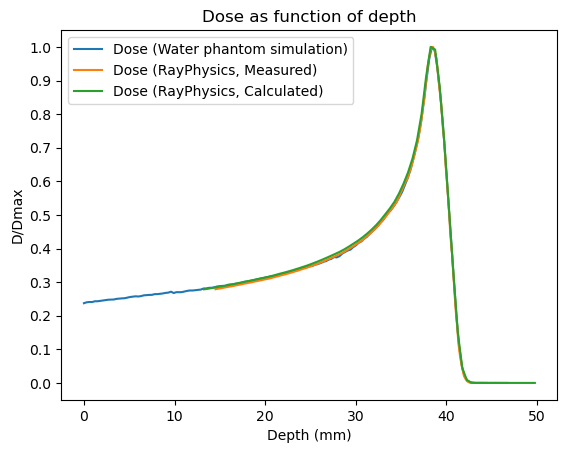

In [17]:
#Plot together with other data to compare
plt.plot(ydata, dosedata/max(dosedata), label='Dose (Water phantom simulation)')
plt.plot(RSdepth_m, RSdose_m, label='Dose (RayPhysics, Measured)')
plt.plot(RSdepth_c, RSdose_c, label='Dose (RayPhysics, Calculated)')
plt.title('Dose as function of depth')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.yticks(np.arange(0, 1.1, 0.1))
plt.legend()

We can conclude that the water phantom simulation closely matches the RayPhysics data.

## Calculating LET in irradiation positions

First interpolate the existing LET and dose data to get a good lookup table for calculations

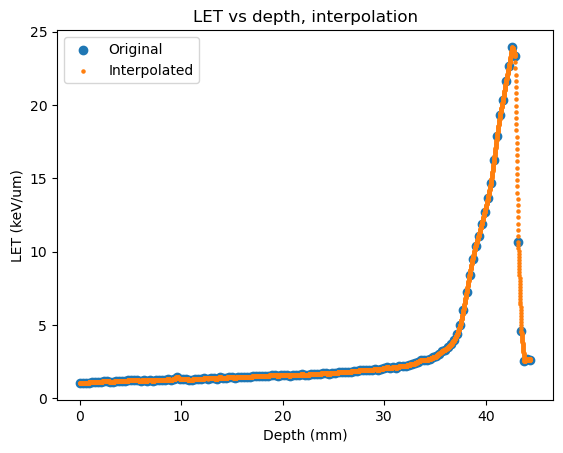

In [6]:
#interpolate data to get depth in steps of 0.01 mm
LET_interp = pd.DataFrame(columns=['Depth', 'LET'])
LET_interp['Depth'] = np.arange(ydata[0], ydata[-1], 0.01)

LET_interp['LET'] = np.interp(LET_interp['Depth'], ydata, letdata)

plt.scatter(ydata, letdata, label='Original')
plt.scatter(LET_interp['Depth'], LET_interp['LET'], label='Interpolated', s=5)
plt.title('LET vs depth, interpolation')
plt.xlabel('Depth (mm)')
plt.ylabel('LET (keV/um)')
plt.legend()

Depth    11.790000
LET       1.328522
Dose      0.532794
Name: 1179, dtype: float64
Depth    40.900000
LET      16.770389
Dose      0.530248
Diff      0.002546
Name: 4090, dtype: float64


C:\Users\bhaan\AppData\Local\Temp\ipykernel_18036\2431795293.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  back_Bragg['Diff'] = abs(back_Bragg['Dose'] - entrance_dose)


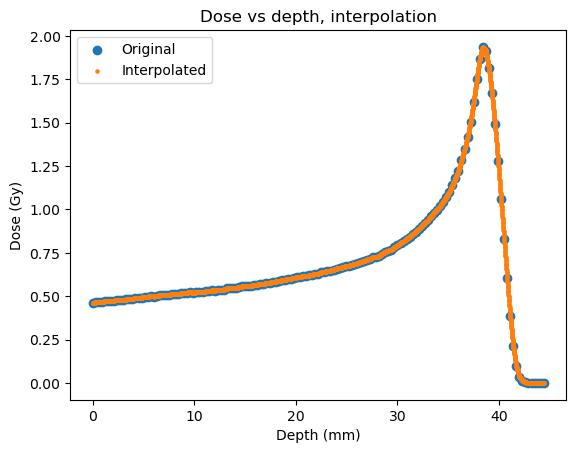

In [ ]:
LET_interp['Dose'] = np.interp(LET_interp['Depth'], ydata, dosedata)

plt.scatter(ydata, dosedata, label='Original')
plt.scatter(LET_interp['Depth'], LET_interp['Dose'], label='Interpolated', s=5)
plt.title('Dose vs depth, interpolation')
plt.xlabel('Depth (mm)')
plt.ylabel('Dose (Gy)')
plt.legend()

First verify the existing irradiation positions.

Low LET position = 10 mm solid water plate + flask bottom
In WET this equals 10.44 mm + 1.34685 = 11.79 mm
So low LET = 11.79 mm depth

High LET position = 10 mm solid water plate + flask bottom + 2 cm range shifter + 6 mm solid water
In WET this equals 10.44 + 1.34685 + 22.84 + 3*(2.11) = 40.96 mm
So high LET is expected at 40.96 mm depth

Expected difference between them is 29.17 mm

In [57]:
#Define low LET position at 11.79 mm depth
start = 1179
low_LET_position = LET_interp.iloc[start]
print('-----Low LET position-----')
print(low_LET_position)

-----Low LET position-----
Depth    11.790000
LET       1.328522
Dose      0.532794
Name: 1179, dtype: float64


In [58]:
#Isolate back end of Bragg peak
back_Bragg = LET_interp.iloc[np.argmax(np.array(LET_interp['Dose'])):len(LET_interp)]
back_Bragg['Diff'] = np.zeros(len(back_Bragg))
#calculate difference with entrance dose
for i in back_Bragg.index:
    diff = abs(back_Bragg.loc[i, 'Dose'] - low_LET_position['Dose'])
    back_Bragg.loc[i, 'Diff'] = diff

#high LET position is where the difference in dose is minimal
high_LET_position = back_Bragg.iloc[np.argmin(np.array(back_Bragg['Diff']))]

print('-----High LET position, (ideal)-----')
print(high_LET_position)

-----High LET position, (ideal)-----
Depth    40.900000
LET      16.770389
Dose      0.530248
Diff      0.002546
Name: 4090, dtype: float64


C:\Users\bhaan\AppData\Local\Temp\ipykernel_18036\1232269054.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  back_Bragg['Diff'] = np.zeros(len(back_Bragg))


This makes a difference of 29.11 mm between the two positions.
That makes sense! The 0.06 mm difference is due to the practicality of solid water plates :)

Let's calculate the LET at the actual high LET position depth of 40.96 mm

In [59]:
#Define actual high LET position at 40.96 mm depth
high_LET_position_actual = LET_interp.iloc[start + 2917]
print('-----High LET position (reality)-----')
print(high_LET_position_actual)

-----High LET position (reality)-----
Depth    40.960000
LET      17.098918
Dose      0.486341
Name: 4096, dtype: float64


To conclude:

low LET = 1.3 keV/um

high LET = 16.8 keV/um

What bugs me about the result is that the low LET dose/high LET dose ratio is 0.53/0.49 = 1.08.

From dosimetry we would expect 1.91/1.99 = 0.96